In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# CODE

In [1]:
import os
import random

DATA_PATH = "/content/skin_dataset/val"   # your dataset path
LIMIT = 50                   # change to 40 if needed

for class_name in os.listdir(DATA_PATH):
    class_path = os.path.join(DATA_PATH, class_name)

    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if os.path.isfile(os.path.join(class_path, img))]

        if len(images) > LIMIT:
            random.shuffle(images)
            images_to_delete = images[LIMIT:]

            for img in images_to_delete:
                os.remove(os.path.join(class_path, img))

            print(f"{class_name}: Reduced to {LIMIT} images")
        else:
            print(f"{class_name}: Already ≤ {LIMIT} images")

print("Dataset reduction complete.")

Measles: Already ≤ 50 images
HFMD: Already ≤ 50 images
Chickenpox: Already ≤ 50 images
Healthy: Already ≤ 50 images
Basal cell carcinoma: Already ≤ 50 images
Squamous cell carcinoma: Already ≤ 50 images
Benign keratosis-like lesions: Already ≤ 50 images
Melanoma: Already ≤ 50 images
Vascular lesions: Already ≤ 50 images
Melanocytic nevi: Already ≤ 50 images
Dermatofibroma: Already ≤ 50 images
Actinic keratoses: Already ≤ 50 images
Cowpox: Already ≤ 50 images
Monkeypox: Already ≤ 50 images
Dataset reduction complete.


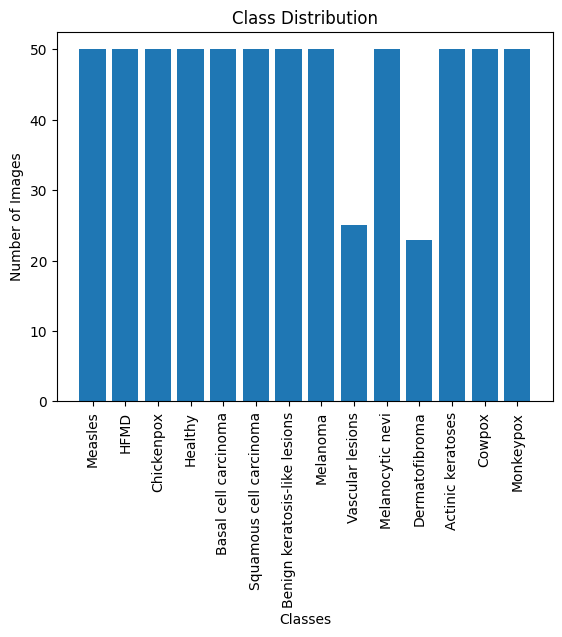

In [2]:
import matplotlib.pyplot as plt

class_counts = {}
for class_name in os.listdir(DATA_PATH):
    class_path = os.path.join(DATA_PATH, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

plt.figure()
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

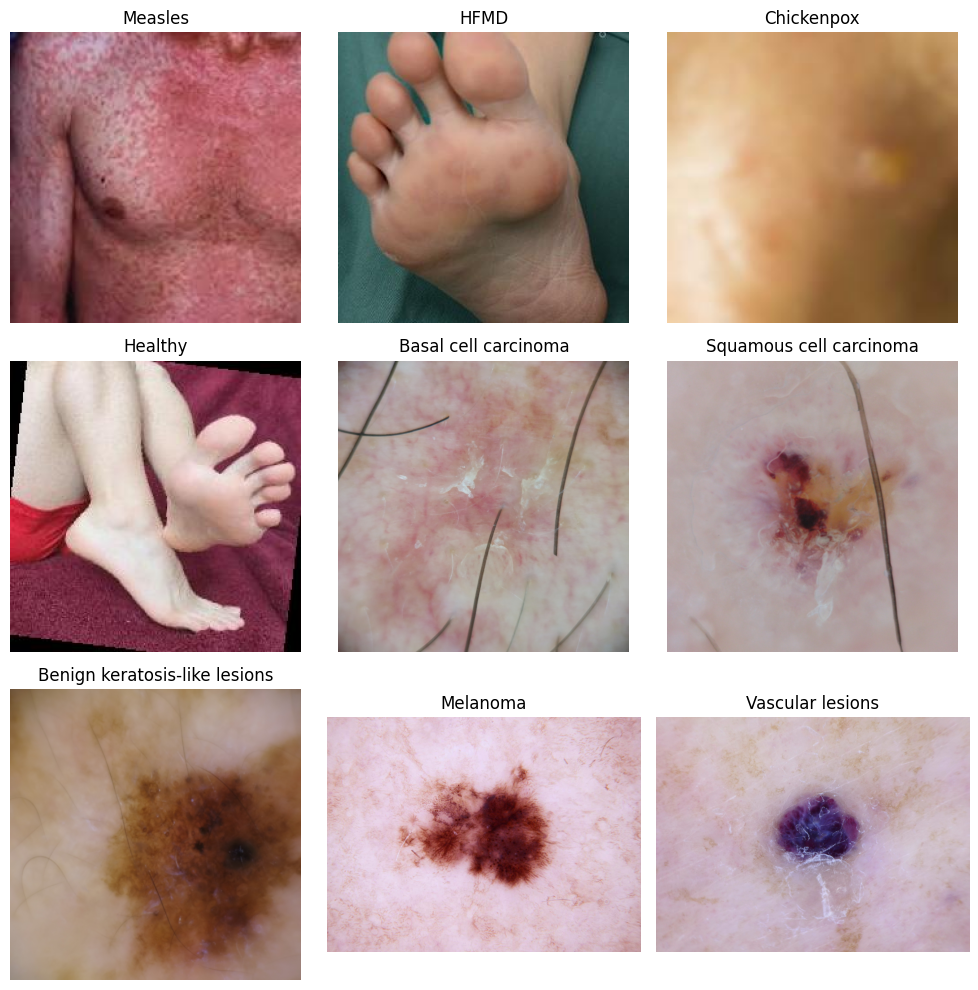

In [3]:
import matplotlib.pyplot as plt
from PIL import Image
import random

plt.figure(figsize=(10,10))

classes = list(class_counts.keys())
for i in range(min(9, len(classes))):
    class_name = classes[i]
    class_path = os.path.join(DATA_PATH, class_name)
    img_name = random.choice(os.listdir(class_path))

    img = Image.open(os.path.join(class_path, img_name))

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
import os
import sys
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 160
BATCH_SIZE = 16
EPOCHS = 10

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Suppress output
original_stdout = sys.stdout
sys.stdout = open(os.devnull, 'w')

train_generator = datagen.flow_from_directory(
    DATA_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    subset='training',
    class_mode='categorical'
)

val_generator = datagen.flow_from_directory(
    DATA_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    subset='validation',
    class_mode='categorical'
)

sys.stdout.close()
sys.stdout = original_stdout

NUM_CLASSES = train_generator.num_classes

In [11]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # IMPORTANT

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
history = model.fit(
    train_generator,
    epochs=20
)

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 15s 430ms/step - accuracy: 0.9661 - loss: 0.1544
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 374ms/step - accuracy: 0.9747 - loss: 0.1008
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 400ms/step - accuracy: 0.9579 - loss: 0.1259
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 406ms/step - accuracy: 0.9631 - loss: 0.1318
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 402ms/step - accuracy: 0.9487 - loss: 0.1494
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 14s 409ms/step - accuracy: 0.9636 - loss: 0.1327
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 14s 412ms/step - accuracy: 0.9808 - loss: 0.1018
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 14s 425ms/step - accuracy: 0.9825 - loss: 0.0822
Epoch 9/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 14s 404ms/step - accuracy: 0.9725 - loss: 0.1090
Epoch 10/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 20s 405ms/step - accuracy: 0.9857 - loss: 0.0785
Epoch 11/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 407ms/step - accuracy: 0.9860 - loss: 0.0727
Epoch 12/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 14

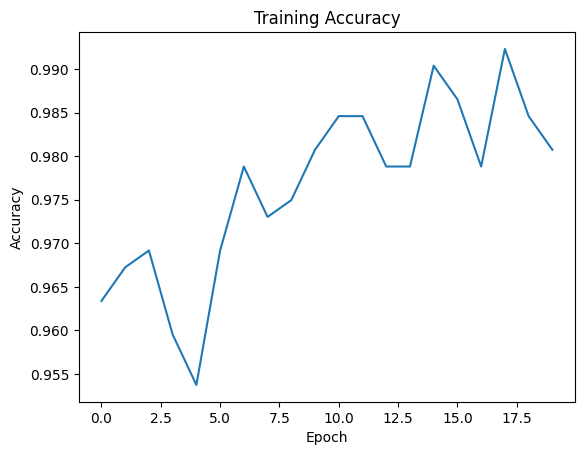

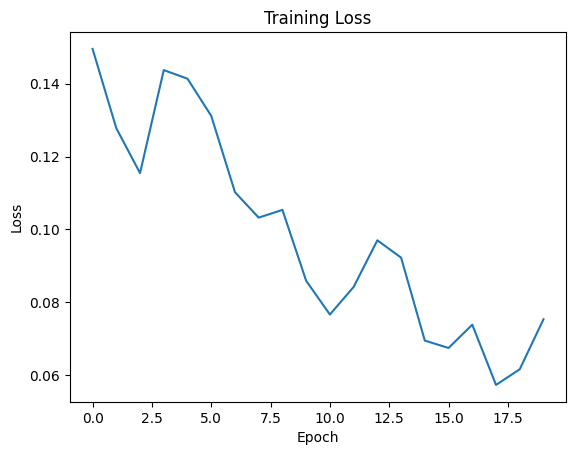

In [27]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
plt.plot(history.history['loss'])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 677ms/step


<Figure size 640x480 with 0 Axes>

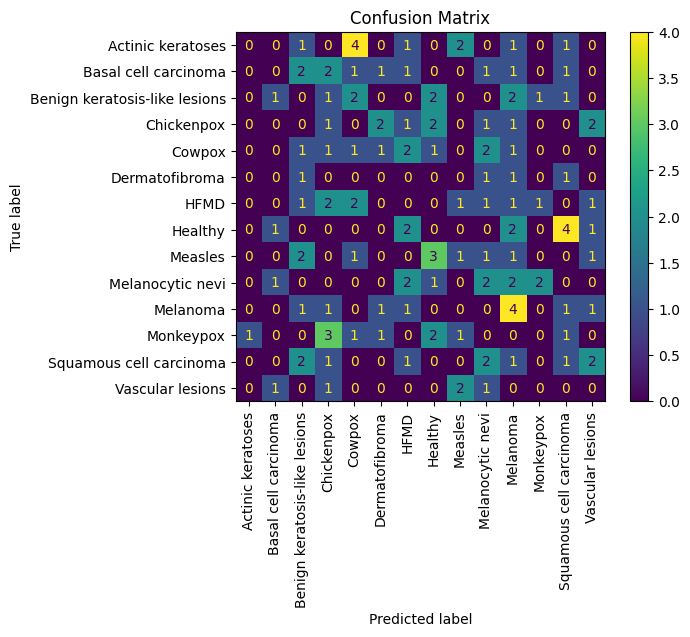

In [28]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

val_generator.reset()
predictions = model.predict(val_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure()
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=list(train_generator.class_indices.keys()))
disp.plot(xticks_rotation=90)
plt.title("Confusion Matrix")
plt.show()

In [36]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

IMG_SIZE = 160   # MUST match training input size
class_names = list(train_generator.class_indices.keys())

In [37]:
image_paths = [
    "/content/melanoma.jpg",
    "/content/pox.jpg"
]

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(160, 160))
    img_array = image.img_to_array(img)
    img_array = preprocess_input(img_array)  # correct normalization
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)

    if prediction.shape[1] == 1:  # Binary classification
        prob = prediction[0][0]
        predicted_class = class_names[int(prob > 0.5)]
        confidence = prob if prob > 0.5 else 1 - prob
    else:  # Multi-class classification
        predicted_index = np.argmax(prediction)
        predicted_class = class_names[predicted_index]
        confidence = prediction[0][predicted_index]

    return img, predicted_class, float(confidence)

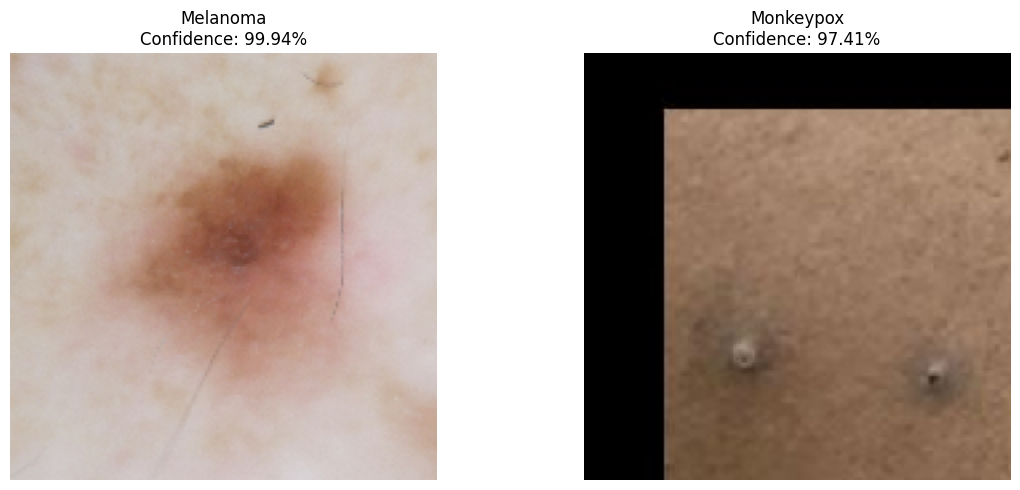

In [39]:
plt.figure(figsize=(12, 5))

for i, img_path in enumerate(image_paths):
    img, label, confidence = predict_image(img_path)

    plt.subplot(1, len(image_paths), i + 1)
    plt.imshow(img)
    plt.title(f"{label}\nConfidence: {confidence*100:.2f}%")
    plt.axis("off")

plt.tight_layout()
plt.show()